In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [4]:
# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# Step 1: Calculate average score across all 3 subjects
df['average score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Step 2: Create Result column — Pass if avg >= 50, else Fail
df['Result'] = df['average score'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

# Verify
print("3a) Result Column Sample:")
print(df[['math score', 'reading score', 'writing score', 'average score', 'Result']].head(5))

print("\nPass/Fail Distribution:")
print(df['Result'].value_counts())

3a) Result Column Sample:
   math score  reading score  writing score  average score Result
0          72             72             74      72.666667   Pass
1          69             90             88      82.333333   Pass
2          90             95             93      92.666667   Pass
3          47             57             44      49.333333   Fail
4          76             78             75      76.333333   Pass

Pass/Fail Distribution:
Result
Pass    897
Fail    103
Name: count, dtype: int64


# Data spliting into Training and Testing

In [5]:
# Step 1: Select Features (X) and Target (y)
X = df[['math score', 'reading score', 'writing score']]   # Input features
y = df['Result']                                            # Target label (Pass/Fail)

# Step 2: Encode target — SVM needs numbers not strings
#          Pass → 1,  Fail → 0
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Encoding:")
print(f"  Classes: {le.classes_}")       # ['Fail' 'Pass']
print(f"  Encoded: Fail=0, Pass=1")

# Step 3: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,        # 20% goes to testing
    random_state=42       # fixed seed for reproducibility
)
print(f"\n3b) Dataset Split:")
print(f"    Total samples    : {len(df)}")
print(f"    Training samples : {len(X_train)}  (80%)")
print(f"    Testing  samples : {len(X_test)}   (20%)")

Label Encoding:
  Classes: ['Fail' 'Pass']
  Encoded: Fail=0, Pass=1

3b) Dataset Split:
    Total samples    : 1000
    Training samples : 800  (80%)
    Testing  samples : 200   (20%)


# Train SVM Model

In [6]:
svm_model = SVC(
    kernel='rbf',      # Radial Basis Function — best for non-linear data
    C=1.0,             # Regularization — controls margin vs misclassification
    gamma='scale',     # Automatically scales based on features
    random_state=42
)

svm_model.fit(X_train, y_train)

print("3c) SVM Model trained successfully!")
print(f"    Kernel : RBF (rbf)")
print(f"    C      : 1.0")
print(f"    Gamma  : scale")

3c) SVM Model trained successfully!
    Kernel : RBF (rbf)
    C      : 1.0
    Gamma  : scale


# Displaying Confusion Matrix and Accuray

3d) Accuracy: 99.50%

Confusion Matrix:
[[ 26   1]
 [  0 173]]

    True  Negatives  (Fail  predicted as Fail) : 26
    False Positives  (Fail  predicted as Pass) : 1
    False Negatives  (Pass  predicted as Fail) : 0
    True  Positives  (Pass  predicted as Pass) : 173


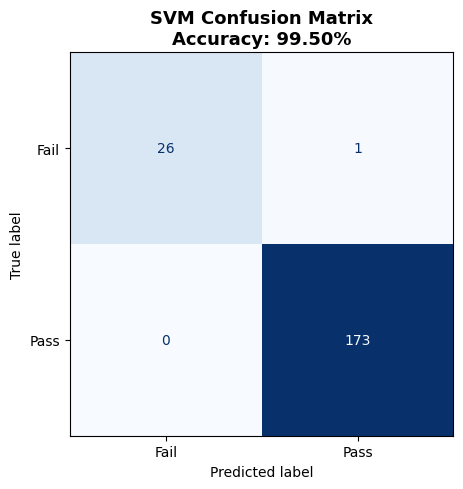

In [7]:
# Step 1: Make predictions on test data
y_pred = svm_model.predict(X_test)

# Step 2: Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"3d) Accuracy: {acc * 100:.2f}%")

# Step 3: Confusion Matrix values
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Step 4: Detailed breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\n    True  Negatives  (Fail  predicted as Fail) : {tn}")
print(f"    False Positives  (Fail  predicted as Pass) : {fp}")
print(f"    False Negatives  (Pass  predicted as Fail) : {fn}")
print(f"    True  Positives  (Pass  predicted as Pass) : {tp}")

# Step 5: Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fail', 'Pass']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'SVM Confusion Matrix\nAccuracy: {acc*100:.2f}%',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150)
plt.show()